# Fig. 4G violin reproduction

This notebook reconstructs the six panels with Seurat `VlnPlot()` using cells from Patient, TIVA, and PDO.

In [62]:
# 1. Import libraries and configure inputs
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tibble)
  library(tidyr)
  library(ggplot2)
  library(patchwork)
})

# Run this notebook from the repository root.
base_dir <- normalizePath(".", mustWork = TRUE)
paths <- list(
  combined = file.path(base_dir, "combined_fig4.rds"),
  flex = file.path(base_dir, "Flex.rds"),
  patient = file.path(base_dir, "zemin_lung.rds"),
  pdo = file.path(base_dir, "lam_reconstructed.rds")
)

comparison_genes <- c("PLVAP", "DLL4", "POSTN", "CXCL12", "NOTCH2", "VEGFA")
comparison_order <- c("Patient", "Assembloid", "PDO")
reference_upper_ticks <- c(PLVAP = 3, DLL4 = 3, POSTN = 5, CXCL12 = 4, NOTCH2 = 3, VEGFA = 6)

In [68]:
# 2. Record software versions
package_names <- c(
  "Seurat", "SeuratObject", "dplyr", "tibble", "tidyr",
  "ggplot2", "patchwork", "rstatix", "ggpubr", "IRkernel"
)

software_versions <- tibble(
  software = c("R", package_names),
  version = c(
    paste(R.version$major, R.version$minor, sep = "."),
    vapply(package_names, function(package_name) {
      as.character(packageVersion(package_name))
    }, character(1))
  )
)

print(software_versions)

# A tibble: 11 × 2
   software     version
   <chr>        <chr>  
 1 R            4.4.3  
 2 Seurat       5.2.1  
 3 SeuratObject 5.2.0  
 4 dplyr        1.2.1  
 5 tibble       3.3.1  
 6 tidyr        1.3.2  
 7 ggplot2      4.0.3  
 8 patchwork    1.3.2  
 9 rstatix      1.1.0  
10 ggpubr       1.0.0  
11 IRkernel     1.3.2  


In [ ]:
# 3. Load and normalize the combined object
load_combined <- function(paths) {
  if (file.exists(paths$combined)) {
    message("Loading prebuilt combined object: ", paths$combined)
    return(readRDS(paths$combined))
  }

  missing_inputs <- names(paths[c("flex", "patient", "pdo")])[
    !file.exists(unlist(paths[c("flex", "patient", "pdo")]))
  ]
  if (length(missing_inputs) > 0) {
    stop(
      "Cannot build combined object. Missing: ",
      paste(missing_inputs, collapse = ", "),
      ". Add the source RDS files or a prepared combined_fig4.rds."
    )
  }

  flex <- readRDS(paths$flex)
  patient <- readRDS(paths$patient)
  pdo <- readRDS(paths$pdo)
  assembloid <- subset(flex, subset = orig.ident == "Assembloid")
  patient <- subset(patient, subset = sample_type == "tumor")
  patient$orig.ident <- "Patient"
  pdo$orig.ident <- "PDO"

  merge(
    assembloid,
    y = c(pdo, patient),
    add.cell.ids = c("Assembloid", "PDO", "Patient"),
    merge.data = FALSE
  )
}

combined <- load_combined(paths)
selected_cells <- colnames(combined)[
  as.character(combined$orig.ident) %in% comparison_order
]
combined <- suppressWarnings(subset(combined, cells = selected_cells))
combined <- JoinLayers(combined, assay = "RNA", layers = "counts")
combined <- NormalizeData(combined, verbose = FALSE)
combined$orig.ident <- factor(combined$orig.ident, levels = comparison_order)

stopifnot("orig.ident" %in% colnames(combined@meta.data))
stopifnot(all(comparison_genes %in% rownames(combined)))
stopifnot(!anyNA(GetAssayData(combined, assay = "RNA", layer = "data")@x))
print(table(combined$orig.ident))

Warning message:
“Removing 21250 cells missing data for vars requested”



   Patient Assembloid        PDO 
      1489       8594       1594 


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


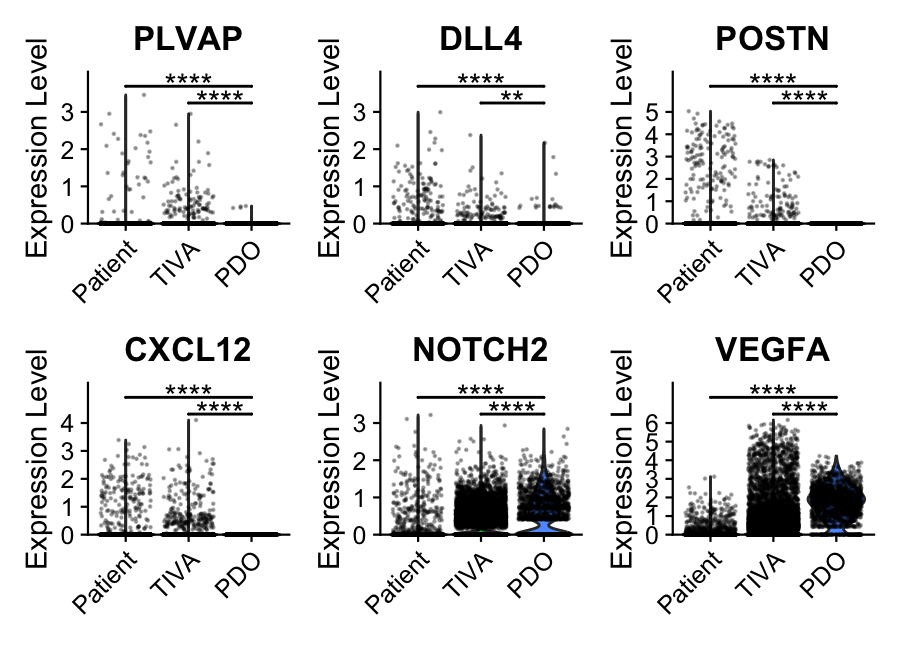

In [66]:
# 4. Reproduce panels with the archived positive-cell-count statistics
combined$plot_group <- factor(
  recode(as.character(combined$orig.ident), Assembloid = "TIVA"),
  levels = c("Patient", "TIVA", "PDO")
)

wilcox_comparisons <- list(
  c("Patient", "PDO"),
  c("TIVA", "PDO")
)

set.seed(123)
positive_count_data <- FetchData(
  combined,
  vars = c(comparison_genes, "plot_group")
) %>%
  group_by(plot_group) %>%
  mutate(subsample = sample(rep(1:500, length.out = n()))) %>%
  ungroup() %>%
  pivot_longer(
    cols = all_of(comparison_genes),
    names_to = "gene",
    values_to = "expression"
  ) %>%
  mutate(positive = expression > 0.5) %>%
  group_by(plot_group, subsample, gene) %>%
  summarise(n_positive = sum(positive), .groups = "drop")

wilcox_pairwise <- positive_count_data %>%
  group_by(gene) %>%
  rstatix::pairwise_wilcox_test(
    n_positive ~ plot_group,
    comparisons = wilcox_comparisons,
    alternative = "two.sided",
    p.adjust.method = "bonferroni",
    exact = FALSE
  ) %>%
  rstatix::add_significance("p.adj")

stopifnot(nrow(wilcox_pairwise) == 12, all(is.finite(wilcox_pairwise$p.adj)))

make_reference_panel <- function(gene_name) {
  stat_data <- wilcox_pairwise %>%
    filter(.data$gene == .env$gene_name) %>%
    mutate(
      y.position = case_when(
        group1 == "Patient" ~ reference_upper_ticks[[gene_name]] * 1.23,
        TRUE ~ reference_upper_ticks[[gene_name]] * 1.08
      )
    )

  VlnPlot(
    combined,
    features = gene_name,
    group.by = "plot_group",
    pt.size = 0.2,
    alpha = 0.3
  ) +
    ggpubr::stat_pvalue_manual(
      stat_data,
      label = "p.adj.signif",
      xmin = "group1",
      xmax = "group2",
      y.position = "y.position",
      tip.length = 0,
      bracket.size = 0.65,
      size = 5.2,
      hide.ns = TRUE
    ) +
    scale_y_continuous(
      breaks = seq(0, reference_upper_ticks[[gene_name]], by = 1),
      expand = expansion(mult = c(0, 0))
    ) +
    coord_cartesian(
      ylim = c(0, reference_upper_ticks[[gene_name]] * 1.36),
      clip = "off"
    ) +
    labs(title = gene_name, x = NULL, y = "Expression Level") +
    NoLegend() +
    theme(
      plot.title = element_text(color = "black"),
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.border = element_blank()
    )
}

reference_plots <- lapply(comparison_genes, make_reference_panel)
reference_grid <- wrap_plots(reference_plots, ncol = 3)

options(repr.plot.width = 6, repr.plot.height = 4.3, repr.plot.res = 150)
reference_grid

In [ ]:
# 5. Show adjusted p-values used for plot brackets
wilcox_pvalues <- wilcox_pairwise %>%
  select(gene, group1, group2, n1, n2, statistic, p, p.adj, p.adj.signif) %>%
  arrange(match(gene, comparison_genes), group1)

print(wilcox_pvalues)

# A tibble: 12 × 9
   gene   group1  group2    n1    n2 statistic         p     p.adj p.adj.signif
   <chr>  <chr>   <chr>  <int> <int>     <dbl>     <dbl>     <dbl> <chr>       
 1 PLVAP  Patient PDO      500   500   132750  1.58e-  8 3.15e-  8 ****        
 2 PLVAP  TIVA    PDO      500   500   137750  2.36e- 13 4.72e- 13 ****        
 3 DLL4   Patient PDO      500   500   141274. 2.43e- 14 4.86e- 14 ****        
 4 DLL4   TIVA    PDO      500   500   129500  1.23e-  3 2.46e-  3 **          
 5 POSTN  Patient PDO      500   500   158000  7.57e- 35 1.51e- 34 ****        
 6 POSTN  TIVA    PDO      500   500   143250  7.48e- 19 1.50e- 18 ****        
 7 CXCL12 Patient PDO      500   500   159750  6.50e- 37 1.30e- 36 ****        
 8 CXCL12 TIVA    PDO      500   500   159250  2.76e- 36 5.51e- 36 ****        
 9 NOTCH2 Patient PDO      500   500    28965  1.24e-108 2.48e-108 ****        
10 NOTCH2 TIVA    PDO      500   500   236869  1.34e-135 2.69e-135 ****        
11 VEGFA  Patient PDO